In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

# Load dataset
df = pd.read_csv("../data/synthetic/orders_data.csv")

# Convert order_time to datetime
df["order_time"] = pd.to_datetime(df["order_time"])

df.head()

,order_id,city,category,customer_type,order_time,distance_km,order_value,delivery_fee,rider_cost,dark_store_cost,discount,delivery_time,gross_margin,contribution_margin,peak_hour
0,1,Chennai,Groceries,Discount-Seeker,2025-03-23 04:18:00,0.78,556.59,33.44,36.64,38.53,61.42,13.06,93.744181,-9.41,0
1,2,Pune,Groceries,Premium,2025-06-05 06:02:00,5.08,589.88,21.22,63.54,23.04,56.31,27.63,125.453680,3.78,0
2,3,Mumbai,Groceries,Premium,2025-02-26 02:07:00,4.55,574.73,21.45,63.81,48.23,0.64,19.84,90.009690,-1.22,0
3,4,Hyderabad,Groceries,Regular,2025-01-23 18:38:00,2.26,419.96,37.76,52.14,40.46,3.17,15.97,67.792234,9.78,0
4,5,Chennai,Beauty,Discount-Seeker,2025-05-06 16:17:00,5.84,324.27,40.76,71.86,45.38,51.73,24.87,61.538436,-66.67,0


In [2]:
daily_orders = (

    df.groupby(
        df["order_time"].dt.date
    )

    ["order_id"]

    .count()

    .reset_index()

)

daily_orders.columns = [
    "date",
    "total_orders"
]

daily_orders.head()

,date,total_orders
0,2025-01-01,129
1,2025-01-02,121
2,2025-01-03,113
3,2025-01-04,109
4,2025-01-05,96


In [3]:
fig = px.line(

    daily_orders,

    x="date",

    y="total_orders",

    title="Daily Order Volume Trend"

)

fig.show()

In [4]:
daily_profit = (

    df.groupby(
        df["order_time"].dt.date
    )

    ["contribution_margin"]

    .sum()

    .reset_index()

)

daily_profit.columns = [
    "date",
    "daily_profit"
]

daily_profit.head()

,date,daily_profit
0,2025-01-01,-1162.84
1,2025-01-02,-1341.13
2,2025-01-03,-1099.19
3,2025-01-04,-1339.15
4,2025-01-05,-1145.83


In [5]:
fig = px.line(

    daily_profit,

    x="date",

    y="daily_profit",

    title="Daily Contribution Profit Trend"

)

fig.show()

In [6]:
forecast_df = daily_orders.copy()

forecast_df.columns = [
    "ds",
    "y"
]

forecast_df.head()

,ds,y
0,2025-01-01,129
1,2025-01-02,121
2,2025-01-03,113
3,2025-01-04,109
4,2025-01-05,96


In [7]:
from prophet import Prophet

# Initialize model
model = Prophet()

# Fit model
model.fit(forecast_df)

21:27:19 - cmdstanpy - INFO - Chain [1] start processing
21:27:20 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
future = model.make_future_dataframe(
    periods=30
)

future.tail()

,ds
206,2025-07-26
207,2025-07-27
208,2025-07-28
209,2025-07-29
210,2025-07-30


In [9]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-01-01,112.560767,95.317790,128.448527,112.560767,112.560767,-1.132844,-1.132844,-1.132844,-1.132844,-1.132844,-1.132844,0.0,0.0,0.0,111.427923
1,2025-01-02,112.537902,96.417497,130.076044,112.537902,112.537902,0.618656,0.618656,0.618656,0.618656,0.618656,0.618656,0.0,0.0,0.0,113.156559
2,2025-01-03,112.515038,96.821328,129.780732,112.515038,112.515038,0.331685,0.331685,0.331685,0.331685,0.331685,0.331685,0.0,0.0,0.0,112.846723
3,2025-01-04,112.492173,94.832259,128.890537,112.492173,112.492173,-0.378395,-0.378395,-0.378395,-0.378395,-0.378395,-0.378395,0.0,0.0,0.0,112.113778
4,2025-01-05,112.469308,96.033001,128.989067,112.469308,112.469308,0.680738,0.680738,0.680738,0.680738,0.680738,0.680738,0.0,0.0,0.0,113.150046


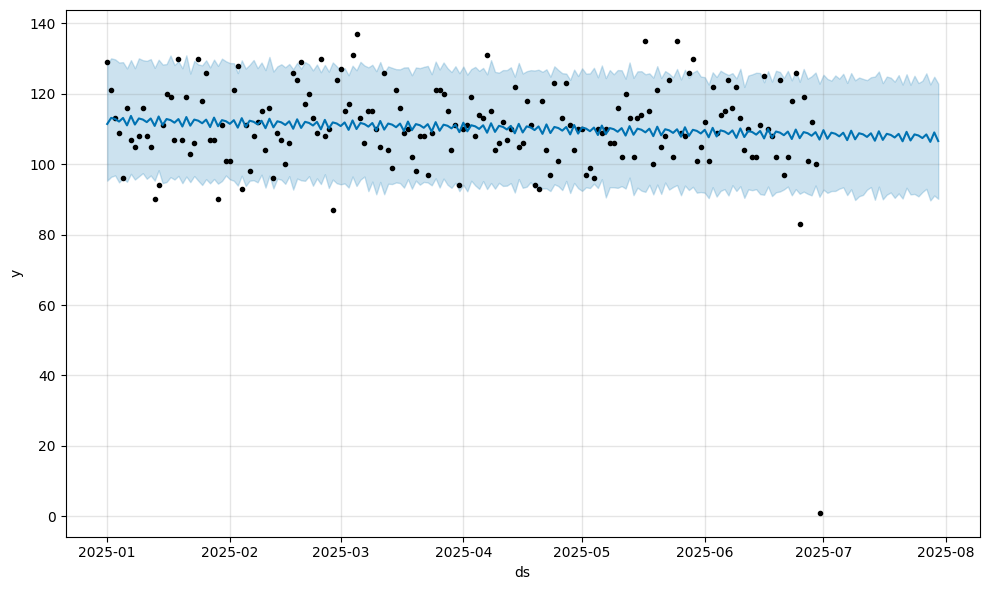

In [10]:
forecast_fig = model.plot(forecast)

In [11]:
profit_forecast_df = daily_profit.copy()

profit_forecast_df.columns = [
    "ds",
    "y"
]

profit_forecast_df.head()

,ds,y
0,2025-01-01,-1162.84
1,2025-01-02,-1341.13
2,2025-01-03,-1099.19
3,2025-01-04,-1339.15
4,2025-01-05,-1145.83


In [12]:
profit_model = Prophet()

profit_model.fit(profit_forecast_df)

21:28:22 - cmdstanpy - INFO - Chain [1] start processing
21:28:22 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
future_profit = profit_model.make_future_dataframe(
    periods=30
)

profit_forecast = profit_model.predict(
    future_profit
)

profit_forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-01-01,-1334.054611,-1693.508766,-670.975299,-1334.054611,-1334.054611,111.210040,111.210040,111.210040,111.210040,111.210040,111.210040,0.0,0.0,0.0,-1222.844571
1,2025-01-02,-1333.929988,-1822.031296,-751.742248,-1333.929988,-1333.929988,52.196380,52.196380,52.196380,52.196380,52.196380,52.196380,0.0,0.0,0.0,-1281.733609
2,2025-01-03,-1333.805365,-1856.885372,-788.713380,-1333.805365,-1333.805365,-30.519230,-30.519230,-30.519230,-30.519230,-30.519230,-30.519230,0.0,0.0,0.0,-1364.324595
3,2025-01-04,-1333.680742,-1897.001938,-780.807507,-1333.680742,-1333.680742,-45.227053,-45.227053,-45.227053,-45.227053,-45.227053,-45.227053,0.0,0.0,0.0,-1378.907795
4,2025-01-05,-1333.556119,-1843.821770,-735.451895,-1333.556119,-1333.556119,45.513004,45.513004,45.513004,45.513004,45.513004,45.513004,0.0,0.0,0.0,-1288.043115


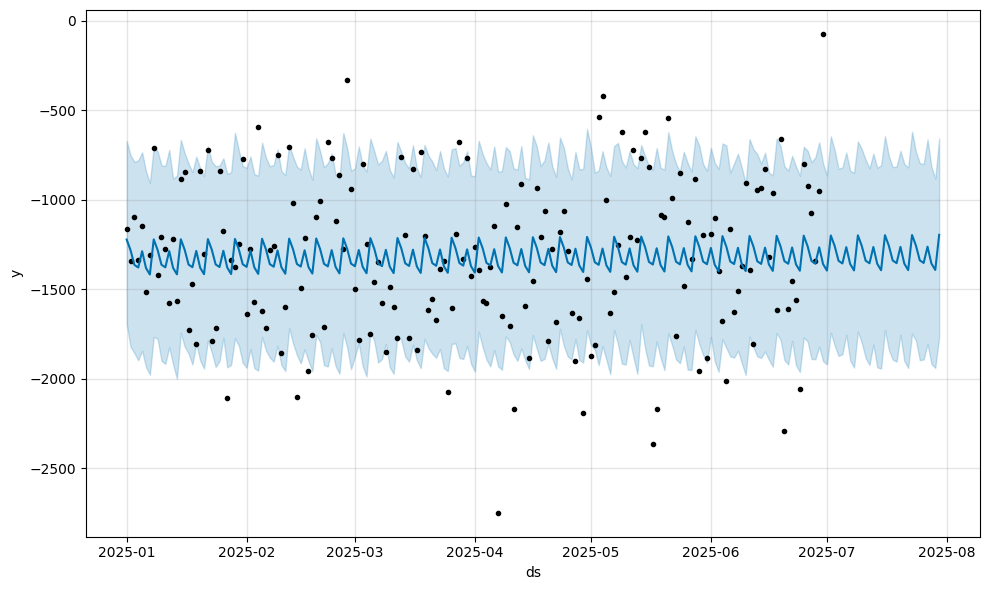

In [14]:
profit_forecast_fig = profit_model.plot(
    profit_forecast
)